In [4]:
from pathlib import Path

# Set your target directory path ('.' means current directory)
directory_path = '.'

# Recursively find all files ending in .csv
csv_files = list(Path(directory_path).rglob('*metrics.csv'))

# Print the full path of each found CSV
for file in csv_files:
    print(file)

thpep/CheMeleon/seed_303/metrics.csv
thpep/CheMeleon/seed_101/metrics.csv
thpep/CheMeleon/seed_202/metrics.csv
thpep/xgboost-morgan/seed_303/metrics.csv
thpep/xgboost-morgan/seed_101/metrics.csv
thpep/xgboost-morgan/seed_202/metrics.csv
thpep/xgboost-rdkit/seed_303/metrics.csv
thpep/xgboost-rdkit/seed_101/metrics.csv
thpep/xgboost-rdkit/seed_202/metrics.csv
thpep/ChemBERTa-77M-MTR/seed_303/metrics.csv
thpep/ChemBERTa-77M-MTR/seed_101/metrics.csv
thpep/ChemBERTa-77M-MTR/seed_202/metrics.csv
cellppd/CheMeleon/seed_303/metrics.csv
cellppd/CheMeleon/seed_101/metrics.csv
cellppd/CheMeleon/seed_202/metrics.csv
cellppd/xgboost-morgan/seed_303/metrics.csv
cellppd/xgboost-morgan/seed_101/metrics.csv
cellppd/xgboost-morgan/seed_202/metrics.csv
cellppd/xgboost-rdkit/seed_303/metrics.csv
cellppd/xgboost-rdkit/seed_101/metrics.csv
cellppd/xgboost-rdkit/seed_202/metrics.csv
cellppd/ChemBERTa-77M-MTR/seed_303/metrics.csv
cellppd/ChemBERTa-77M-MTR/seed_101/metrics.csv
cellppd/ChemBERTa-77M-MTR/seed_20

In [5]:
import pandas as pd
from pathlib import Path

directory_path = Path('.')
datasets = ['amp_hgt', 'cellppd', 'thpep']

# Optimization: Only search for 'metrics.csv' rather than all CSVs
metrics_files = list(directory_path.rglob('metrics.csv'))

for dataset in datasets:
    output_name = f"{dataset}_all.csv"
    df_list = []

    for file in metrics_files:
        file_path_str = str(file)
        
        # Filter based on your criteria
        if dataset in file_path_str:
            df_list.append(pd.read_csv(file))

    # Only concatenate and save if matching files were found
    if df_list:
        combined_df = pd.concat(df_list, ignore_index=True)
        combined_df.to_csv(output_name, index=False)
        print(f"Saved {output_name}: Concatenated {len(df_list)} files.")
    else:
        print(f"No files found for dataset: {dataset}")

Saved amp_hgt_all.csv: Concatenated 12 files.
Saved cellppd_all.csv: Concatenated 12 files.
Saved thpep_all.csv: Concatenated 12 files.


In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import matthews_corrcoef, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

directory_path = Path('.')

# 1. Define the roles for each metric
metric_roles = {
    'mcc': 'primary', 
    'f1': 'primary', 
    'auroc': 'primary',
    'accuracy': 'secondary',
    'precision': 'secondary', 
    'recall': 'secondary'
}

# Define mapping from folder prefix to standardized task_id
task_mapping = {
    'amp_': 'amp_hgt',
    'cellppd_': 'cellppd',
    'thpep_': 'thpep'
}

# Initialize a dictionary to store the new calculated rows using standardized names
new_metrics = {
    'amp_hgt': [],
    'cellppd': [],
    'thpep': []
}

# 3. Find and process all relevant results.csv files
for file in directory_path.rglob('*results.csv'):
    
    # Filter for peptideclm in the path
    if 'peptideclm' in str(file):
        parts = file.parts
        # Expected structure: task_folder / model_family / model_variant / seed_### / *results.csv
        try:
            seed_idx = next(i for i, part in enumerate(parts) if 'seed_' in part)
            
            seed = int(parts[seed_idx].replace('seed_', ''))
            model_variant = parts[seed_idx - 1]
            model_family = parts[seed_idx - 2]
            raw_task_folder = parts[seed_idx - 3]
            
        except (StopIteration, IndexError, ValueError):
            print(f"Skipping {file}: Path structure does not match expected format.")
            continue

        # Match the raw folder name to the standardized task_id
        task_id = None
        lower_folder = raw_task_folder.lower()
        for prefix, standardized_name in task_mapping.items():
            if lower_folder.startswith(prefix):
                task_id = standardized_name
                break
        
        # If the folder doesn't match our expected prefixes, skip it
        if not task_id:
            print(f"Skipping {file}: Folder '{raw_task_folder}' does not match known task prefixes.")
            continue

        # Load the predictions
        df_preds = pd.read_csv(file)
        
        # Drop rows with NaN values in the essential columns
        df_preds = df_preds.dropna(subset=['true_label', 'predicted_label'])
        
        # Guard clause: skip if the file is empty or only contains one class
        if df_preds.empty:
            print(f"Skipping {file}: No valid data remaining after dropping NaNs.")
            continue
            
        y_true = df_preds['true_label']
        y_pred_logits = df_preds['predicted_label'] 
        
        if len(y_true.unique()) < 2:
            print(f"Skipping {file}: AUROC requires both classes (0 and 1) to be present.")
            continue

        # Find the best threshold maximizing MCC
        candidate_thresholds = np.unique(y_pred_logits)
        best_threshold = 0.0
        best_mcc = -1.0
        
        for t in candidate_thresholds:
            y_pred_binary = (y_pred_logits >= t).astype(int)
            if len(np.unique(y_pred_binary)) == 2:
                current_mcc = matthews_corrcoef(y_true, y_pred_binary)
                if current_mcc > best_mcc:
                    best_mcc = current_mcc
                    best_threshold = t
        
        threshold = best_threshold
        y_pred_binary = (y_pred_logits >= threshold).astype(int)

        # Calculate metrics
        calculated = {
            'mcc': matthews_corrcoef(y_true, y_pred_binary),
            'f1': f1_score(y_true, y_pred_binary, zero_division=0),
            'accuracy': accuracy_score(y_true, y_pred_binary),
            'precision': precision_score(y_true, y_pred_binary, zero_division=0),
            'recall': recall_score(y_true, y_pred_binary, zero_division=0),
            'auroc': roc_auc_score(y_true, y_pred_logits) 
        }

        # Format rows for the dataframe
        for m_name, m_value in calculated.items():
            row = {
                'task_id': task_id,       # Standardized name saved inside the CSV
                'model_family': model_family,
                'model_variant': model_variant,
                'seed': seed,
                'split_id': 'test',
                'metric_name': m_name,
                'metric_value': m_value,
                'metric_role': metric_roles[m_name]
            }
            
            new_metrics[task_id].append(row)

# 4. Append the new data to the existing _all.csv files
for task_id, rows in new_metrics.items():
    if not rows:
        continue
        
    new_df = pd.DataFrame(rows)
    output_name = f"{task_id}_all.csv"   # Saves to amp_hgt_all.csv, cellppd_all.csv, etc.
    
    if Path(output_name).exists():
        existing_df = pd.read_csv(output_name)
        combined_df = pd.concat([existing_df, new_df], ignore_index=True)
        combined_df.to_csv(output_name, index=False)
        print(f"Appended {len(new_df)} calculated rows to {output_name}")
    else:
        new_df.to_csv(output_name, index=False)
        print(f"Created {output_name} with {len(new_df)} calculated rows (original not found).")

Appended 54 calculated rows to amp_hgt_all.csv
Appended 54 calculated rows to cellppd_all.csv
Appended 54 calculated rows to thpep_all.csv


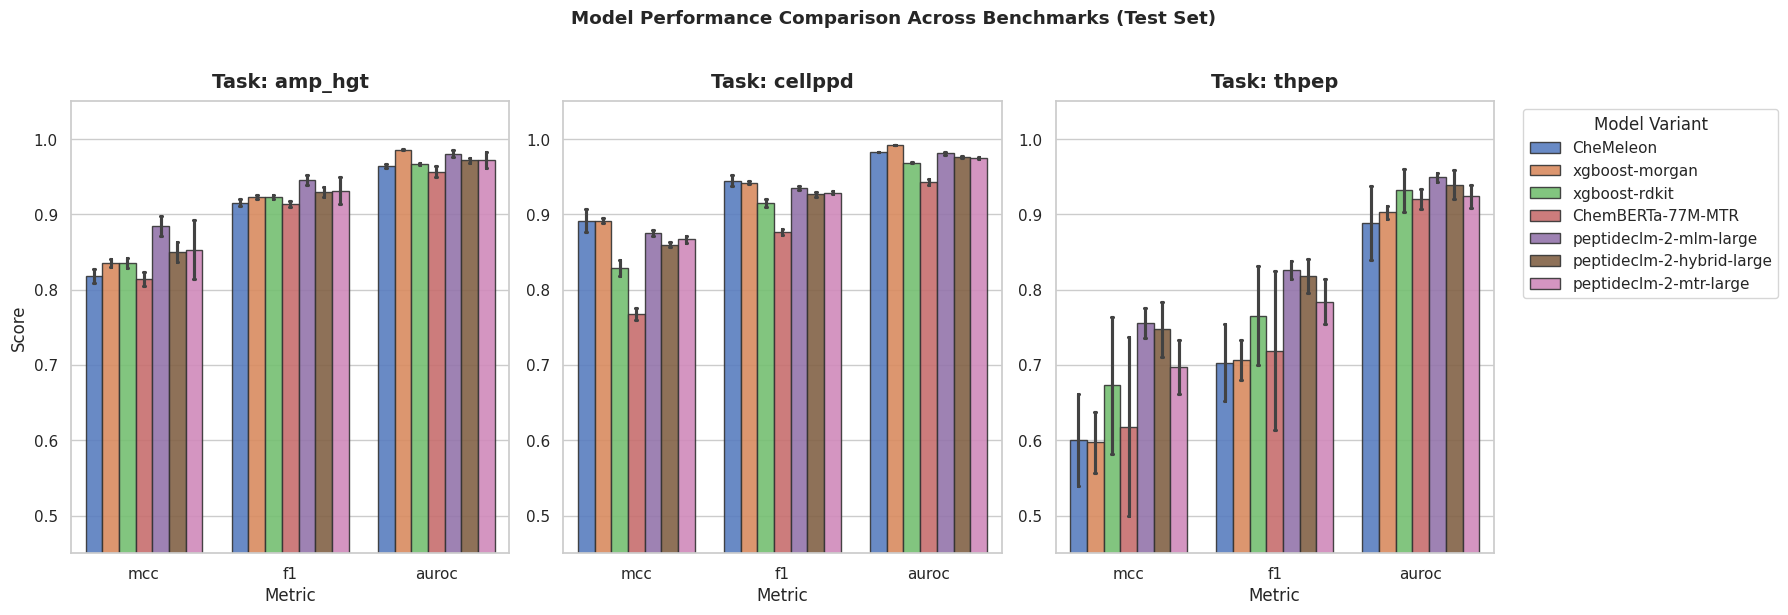

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14})

datasets = ["amp_hgt", "cellppd", "thpep"]
primary_metrics = ["mcc", "f1", "auroc"]

# 1. Load and combine the aggregated data from the three files
all_data = []
for dataset in datasets:
    file_path = Path(f"{dataset}_all.csv")
    if file_path.exists():
        all_data.append(pd.read_csv(file_path))

if not all_data:
    print("No consolidated CSV files found to plot.")
else:
    df_plot = pd.concat(all_data, ignore_index=True)

    # Filter to only look at primary metrics on the test split
    df_plot = df_plot[
        (df_plot["metric_name"].isin(primary_metrics))
        & (df_plot["split_id"] == "test")
    ]

    # 2. Set up a grid of subplots (one for each dataset/task)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(
        "Model Performance Comparison Across Benchmarks (Test Set)",
        weight="bold",
        y=1.02,
    )

    # Use a clean, distinct palette for the different model variants
    unique_variants = df_plot["model_variant"].unique()
    palette = sns.color_palette("muted", n_colors=len(unique_variants))
    color_map = dict(zip(unique_variants, palette))

    for idx, dataset in enumerate(datasets):
        ax = axes[idx]
        df_sub = df_plot[df_plot["task_id"] == dataset]

        if df_sub.empty:
            ax.text(
                0.5,
                0.5,
                f"No data for {dataset}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(f"Task: {dataset}")
            continue

        # 3. Draw the barplot (Seaborn automatically computes mean and error bars for seeds)
        sns.barplot(
            data=df_sub,
            x="metric_name",
            y="metric_value",
            hue="model_variant",
            palette=color_map,
            errorbar="sd",
            capsize=0.08,
            edgecolor="0.2",
            alpha=0.9,
            ax=ax,
        )

        ax.set_title(f"Task: {dataset}", weight="semibold", pad=10)
        ax.set_xlabel("Metric")
        ax.set_ylabel("Score" if idx == 0 else "")
        ax.set_ylim(0.45, 1.05)

        # Handle legends cleanly: only show it on the far-right plot to avoid clutter
        if idx == len(datasets) - 1:
            ax.legend(
                title="Model Variant",
                bbox_to_anchor=(1.05, 1),
                loc="upper left",
                frameon=True,
            )
        else:
            ax.get_legend().remove()

    plt.tight_layout()
    plt.show()

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import matthews_corrcoef, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

directory_path = Path('.')
datasets = ['amp_hgt', 'cellppd', 'thpep']

# 1. Define the roles for each metric
metric_roles = {
    'mcc': 'primary', 
    'f1': 'primary', 
    'auroc': 'primary',
    'accuracy': 'secondary',
    'precision': 'secondary', 
    'recall': 'secondary'
}

# 2. Initialize a dictionary to store the new calculated rows
new_metrics = {dataset: [] for dataset in datasets}

# 3. Find and process all relevant results.csv files
for file in directory_path.rglob('*results.csv'):
    
    # Filter for peptideclm in the path
    if 'peptideclm' in str(file):
        parts = file.parts
        # Locate the 'seed_' directory to reliably extract the path hierarchy backwards
        # Expected structure: task_id / model_family / model_variant / seed_### / *results.csv
        try:
            seed_idx = next(i for i, part in enumerate(parts) if 'seed_' in part)
            
            seed = int(parts[seed_idx].replace('seed_', ''))
            model_variant = parts[seed_idx - 1]
            model_family = parts[seed_idx - 2]
            task_id = parts[seed_idx - 3]
            
        except (StopIteration, IndexError, ValueError):
            print(f"Skipping {file}: Path structure does not match expected format.")
            continue

        # Load the predictions
        df_preds = pd.read_csv(file)
        
        # Drop rows with NaN values in the essential columns
        df_preds = df_preds.dropna(subset=['true_label', 'predicted_label'])
        
        # Guard clause: skip if the file is empty or only contains one class
        if df_preds.empty:
            print(f"Skipping {file}: No valid data remaining after dropping NaNs.")
            continue
            
        y_true = df_preds['true_label']
        y_pred_logits = df_preds['predicted_label'] 
        
        if len(y_true.unique()) < 2:
            print(f"Skipping {file}: AUROC requires both classes (0 and 1) to be present.")
            continue

        # For logits, the standard decision boundary is 0.0
        threshold = 0.0
        ### find the best threshhold
        # 1. Generate candidate thresholds across the distribution of your logits
        # We look at every unique logit value present to find the optimal cut-point
        # candidate_thresholds = np.unique(y_pred_logits)
        
        # best_threshold = 0.0
        # best_mcc = -1.0
        
        # # 2. Iterate to find the threshold that maximizes MCC
        # for t in candidate_thresholds:
        #     y_pred_binary = (y_pred_logits >= t).astype(int)
        #     # We only calculate MCC if both classes are present at this threshold
        #     if len(np.unique(y_pred_binary)) == 2:
        #         current_mcc = matthews_corrcoef(y_true, y_pred_binary)
        #         if current_mcc > best_mcc:
        #             best_mcc = current_mcc
        #             best_threshold = t
        
        # # 3. Apply the optimized threshold
        # threshold = best_threshold
        y_pred_binary = (y_pred_logits >= threshold).astype(int)

        # Calculate metrics
        calculated = {
            'mcc': matthews_corrcoef(y_true, y_pred_binary),
            'f1': f1_score(y_true, y_pred_binary, zero_division=0),
            'accuracy': accuracy_score(y_true, y_pred_binary),
            'precision': precision_score(y_true, y_pred_binary, zero_division=0),
            'recall': recall_score(y_true, y_pred_binary, zero_division=0),
            'auroc': roc_auc_score(y_true, y_pred_logits) 
        }

        # Format rows for the dataframe
        for m_name, m_value in calculated.items():
            row = {
                'task_id': task_id,
                'model_family': model_family,
                'model_variant': model_variant,
                'seed': seed,
                'split_id': 'test',
                'metric_name': m_name,
                'metric_value': m_value,
                'metric_role': metric_roles[m_name]
            }
            
            if task_id in new_metrics:
                new_metrics[task_id].append(row)

# 4. Append the new data to the existing _all.csv files
for task_id, rows in new_metrics.items():
    if not rows:
        continue
        
    new_df = pd.DataFrame(rows)
    input_name = f"{task_id}_all.csv"
    output_name = f"{task_id}_all2.csv"
    
    if Path(input_name).exists():
        existing_df = pd.read_csv(input_name)
        # remove rows with model_family as peptideclm
        existing_df[existing_df["model_family"] != "peptideclm"]
        combined_df = pd.concat([existing_df, new_df], ignore_index=True)
        combined_df.to_csv(output_name, index=False)
        print(f"Appended {len(new_df)} calculated rows to {output_name}")
    else:
        new_df.to_csv(output_name, index=False)
        print(f"Created {output_name} with {len(new_df)} calculated rows (original not found).")

Appended 54 calculated rows to amp_hgt_all2.csv
Appended 54 calculated rows to cellppd_all2.csv
Appended 54 calculated rows to thpep_all2.csv


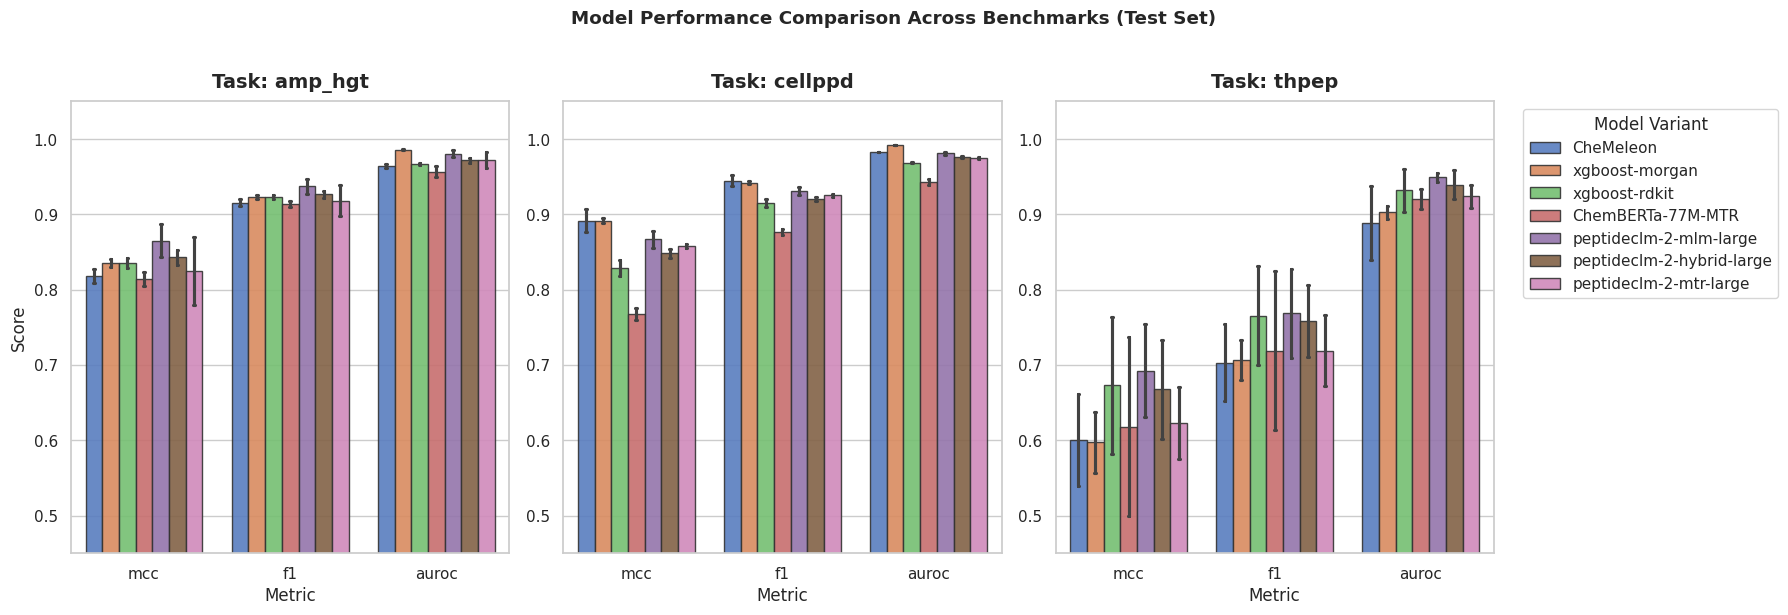

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14})

datasets = ["amp_hgt", "cellppd", "thpep"]
primary_metrics = ["mcc", "f1", "auroc"]

# 1. Load and combine the aggregated data from the three files
all_data = []
for dataset in datasets:
    file_path = Path(f"{dataset}_all2.csv")
    if file_path.exists():
        all_data.append(pd.read_csv(file_path))

if not all_data:
    print("No consolidated CSV files found to plot.")
else:
    df_plot = pd.concat(all_data, ignore_index=True)

    # Filter to only look at primary metrics on the test split
    df_plot = df_plot[
        (df_plot["metric_name"].isin(primary_metrics))
        & (df_plot["split_id"] == "test")
    ]

    # 2. Set up a grid of subplots (one for each dataset/task)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(
        "Model Performance Comparison Across Benchmarks (Test Set)",
        weight="bold",
        y=1.02,
    )

    # Use a clean, distinct palette for the different model variants
    unique_variants = df_plot["model_variant"].unique()
    palette = sns.color_palette("muted", n_colors=len(unique_variants))
    color_map = dict(zip(unique_variants, palette))

    for idx, dataset in enumerate(datasets):
        ax = axes[idx]
        df_sub = df_plot[df_plot["task_id"] == dataset]

        if df_sub.empty:
            ax.text(
                0.5,
                0.5,
                f"No data for {dataset}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(f"Task: {dataset}")
            continue

        # 3. Draw the barplot (Seaborn automatically computes mean and error bars for seeds)
        sns.barplot(
            data=df_sub,
            x="metric_name",
            y="metric_value",
            hue="model_variant",
            palette=color_map,
            errorbar="sd",
            capsize=0.08,
            edgecolor="0.2",
            alpha=0.9,
            ax=ax,
        )

        ax.set_title(f"Task: {dataset}", weight="semibold", pad=10)
        ax.set_xlabel("Metric")
        ax.set_ylabel("Score" if idx == 0 else "")
        ax.set_ylim(0.45, 1.05)

        # Handle legends cleanly: only show it on the far-right plot to avoid clutter
        if idx == len(datasets) - 1:
            ax.legend(
                title="Model Variant",
                bbox_to_anchor=(1.05, 1),
                loc="upper left",
                frameon=True,
            )
        else:
            ax.get_legend().remove()

    plt.tight_layout()
    plt.show()

In [8]:
df_sub[(df_sub["model_family"] == "peptideclm") & (df_sub["metric_name"] == "mcc")]

,task_id,model_family,model_variant,seed,split_id,metric_name,metric_value,metric_role
324,thpep,peptideclm,peptideclm-2-mlm-large,303,test,mcc,0.724812,primary
330,thpep,peptideclm,peptideclm-2-mlm-large,101,test,mcc,0.620820,primary
336,thpep,peptideclm,peptideclm-2-mlm-large,202,test,mcc,0.731977,primary
342,thpep,peptideclm,peptideclm-2-hybrid-large,303,test,mcc,0.719540,primary
348,thpep,peptideclm,peptideclm-2-hybrid-large,101,test,mcc,0.592875,primary
354,thpep,peptideclm,peptideclm-2-hybrid-large,202,test,mcc,0.689893,primary
360,thpep,peptideclm,peptideclm-2-mtr-large,303,test,mcc,0.622721,primary
366,thpep,peptideclm,peptideclm-2-mtr-large,101,test,mcc,0.575924,primary
372,thpep,peptideclm,peptideclm-2-mtr-large,202,test,mcc,0.670451,primary


In [9]:
# 1. Filter for the peptideclm model family and the MCC metric
peptide_mcc = df_plot[
    (df_plot["model_family"] == "peptideclm") & 
    (df_plot["model_variant"] == "peptideclm-2-mlm-large") &
    (df_plot["metric_name"] == "mcc")
]

# 2. Calculate the average MCC for each model variant across the different seeds
avg_scores = peptide_mcc.groupby(["task_id", "model_variant"])["metric_value"].mean().reset_index()

# 3. Retrieve the specific model variant with the highest average MCC for each dataset
best_scores = avg_scores.loc[avg_scores.groupby("task_id")["metric_value"].idxmax()]

print(best_scores)

   task_id           model_variant  metric_value
0  amp_hgt  peptideclm-2-mlm-large      0.864943
1  cellppd  peptideclm-2-mlm-large      0.866835
2    thpep  peptideclm-2-mlm-large      0.692536
